# Regressão Linear

### Teste de Heterodasticidade
        (Breusch-Pagan, Goldfeld-Quandt, Harrison-McCabe)
Esses testes são usados principalmente em regressão linear, porque todos eles verificam heterocedasticidade dos resíduos.

Podem ser usados em outros modelos que também possuem:
   * resíduos
   * estrutura paramétrica
   * hipótese de variância constante

Exemplos:
   * regressão múltipla
   * alguns modelos lineares generalizados
   * séries temporais
   * econometria em geral

In [2]:
from cinza.Estats import *
df = pd.read_excel("data/regressao_linear.xlsx")
df.head()

,ID,Orçamento de Publicidade (R$),Tempo médio entrega (dias),Visitas ao Site,Número de Vendedores,Total de Vendas (R$)
0,1,17795,2,8629,6,77176.5
1,2,2860,6,2016,7,28124.0
2,3,7390,4,8869,9,47340.0
3,4,13964,4,7439,9,77307.0
4,5,13284,2,8892,13,81155.0


In [3]:
teste_heterocedasticidade(df, y="Total de Vendas (R$)", x="Orçamento de Publicidade (R$)")

,statistic,p-value
Breusch-Pagan,0.021517,0.883378
Goldfeld-Quandt,0.743333,0.781238
White,0.024255,0.987946


In [4]:
teste_heterocedasticidade(
    df, y="Total de Vendas (R$)",
    x=[
        "Orçamento de Publicidade (R$)",
        "Visitas ao Site",
        "Tempo médio entrega (dias)"
    ]
)

,statistic,p-value
Breusch-Pagan,2.718192,0.437145
Goldfeld-Quandt,0.446349,0.977811
White,9.329950,0.407391


### Testes de Autocorrelação e Colinearidade

#### Autocorrelação dos Resíduos

A autocorrelação ocorre quando os resíduos do modelo apresentam dependência entre si.
Em outras palavras, os erros deixam de ser aleatórios e passam a seguir algum padrão.

Em regressões lineares, espera-se que os resíduos sejam independentes.

Para verificar autocorrelação foi utilizada a estatística de Durbin-Watson.

Interpretação da estatística DW:

| DW | Interpretação |
|---|---|
| ≈ 2 | Sem autocorrelação |
| < 2 | Autocorrelação positiva |
| > 2 | Autocorrelação negativa |
| Próximo de 0 | Forte autocorrelação positiva |
| Próximo de 4 | Forte autocorrelação negativa |

A autocorrelação residual pode indicar:

- Omissão de variáveis importantes
- Tendência temporal
- Sazonalidade
- Má especificação do modelo

Quando presente, os erros-padrão e testes de hipótese podem se tornar inválidos.

---

#### Colinearidade

A colinearidade ocorre quando variáveis independentes apresentam forte correlação entre si.

Isso dificulta a separação do efeito individual de cada variável explicativa no modelo.

Para avaliar colinearidade foi utilizado o Variance Inflation Factor (VIF).

Interpretação do VIF:

| VIF | Interpretação |
|---|---|
| 1 | Sem colinearidade |
| 1 a 5 | Baixa/moderada |
| > 5 | Problemática |
| > 10 | Grave |

Também foi calculada a tolerância:       $$Tolerância = \frac{1}{VIF}$$

A tolerância normalmente fica no intervalo:

$0 < Tolerância < 1$

Valores baixos de tolerância indicam maior colinearidade.
| VIF | Tolerância | Interpretação     |
| --- | ---------: | ----------------- |
| 1   |       1.00 | Sem colinearidade |
| 2   |       0.50 | Baixa             |
| 5   |       0.20 | Problemática      |
| 10  |       0.10 | Grave             |
| 20  |       0.05 | Muito grave       |

A presença de colinearidade pode causar:

- Instabilidade nos coeficientes
- Aumento dos erros-padrão
- Dificuldade de interpretação
- Perda de significância estatística


In [6]:
from cinza.Estats import *
df = pd.read_excel("data/regressao_linear.xlsx")
df.head()

,ID,Orçamento de Publicidade (R$),Tempo médio entrega (dias),Visitas ao Site,Número de Vendedores,Total de Vendas (R$)
0,1,17795,2,8629,6,77176.5
1,2,2860,6,2016,7,28124.0
2,3,7390,4,8869,9,47340.0
3,4,13964,4,7439,9,77307.0
4,5,13284,2,8892,13,81155.0


In [7]:
r = regressao_linear_simples(df, y="Total de Vendas (R$)", x="Orçamento de Publicidade (R$)", alpha=0.05)

# teste de autocorrelação
teste_durbin_watson(r["residuos"])

,Autocorrelação,Estatística DW
Durbin-Watson,-0.102329,2.204658


Autocorrelação

In [8]:
r = regressao_linear_simples(df, y="Total de Vendas (R$)", x="Orçamento de Publicidade (R$)", alpha=0.05)

# teste de autocorrelação
teste_durbin_watson(r["residuos"])

,Autocorrelação,Estatística DW
Durbin-Watson,-0.102329,2.204658


Colinearidade

In [9]:
estatistica_colinearidade(
    df,
    ["Orçamento de Publicidade (R$)", "Tempo médio entrega (dias)", "Visitas ao Site"]
)

,VIF,Tolerância
Variável,,
Orçamento de Publicidade (R$),1.594,0.627
Tempo médio entrega (dias),1.637,0.611
Visitas ao Site,1.043,0.959


### Regressão Linear simples
$y = β0 + β1*x1$

In [11]:
from cinza.Estats import *
df = pd.read_excel("data/regressao_linear.xlsx")
df.head()

,ID,Orçamento de Publicidade (R$),Tempo médio entrega (dias),Visitas ao Site,Número de Vendedores,Total de Vendas (R$)
0,1,17795,2,8629,6,77176.5
1,2,2860,6,2016,7,28124.0
2,3,7390,4,8869,9,47340.0
3,4,13964,4,7439,9,77307.0
4,5,13284,2,8892,13,81155.0


In [12]:
r = regressao_linear_simples(
    df, y="Total de Vendas (R$)", x="Orçamento de Publicidade (R$)", alpha=0.05
)

In [13]:
r["modelo"]

,Resultado
R,0.9178
R²,0.8423
F,309.7522
gl1,1.0000
gl2,58.0000
p-value,0.0000


In [14]:
r["coeficientes"]

,Estimativas,Erro-padrão,Lim. inferior,Lim. superior,t,p-value
Intercepto,19820.6179,2314.5389,15187.5649,24453.6709,8.5635,0.0
Orçamento de Publicidade (R$),3.6355,0.2066,3.2220,4.0489,17.5998,0.0


**Interpretação dos coeficientes**
- Intercepto (β0=19.820,62)

O intercepto representa o valor médio esperado da variável resposta quando o orçamento de publicidade é igual a zero.

Neste caso, mesmo que a empresa não invista nada em publicidade, o modelo estima um valor médio de aproximadamente R$ 19.820,62 para a variável dependente.

Além disso, o intervalo de confiança de 95% para o intercepto varia de 15.187,56 a 24.453,67, indicando que o valor verdadeiro do intercepto na população provavelmente está dentro desse intervalo.

___
**Coeficiente do Orçamento de Publicidade (β1=3,6355)**

O coeficiente angular indica a variação média esperada na variável resposta para cada aumento de 1,00 no orçamento de publicidade.

Assim, para cada real adicional investido em publicidade, espera-se um aumento médio de aproximadamente 3,64 na variável resposta.

Em termos práticos:

Um aumento de 100 em publicidade está associado a um aumento médio de aproximadamente 363,55 na variável resposta.
Um aumento de 1.000 em publicidade está associado a um aumento médio de aproximadamente 3.635,50 na variável resposta.

O intervalo de confiança de 95% para esse coeficiente vai de 3,2220 a 4,0489, sugerindo que o efeito verdadeiro do investimento em publicidade é positivo e substancial.

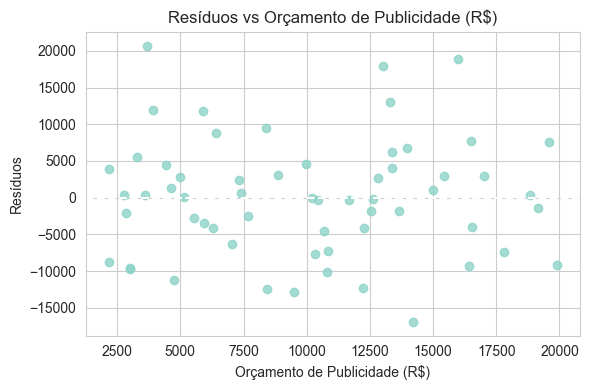

In [15]:
v_plot_residuos(df, residuos=r["residuos"], colunas="Orçamento de Publicidade (R$)")

### Regressão Linear Multipla
- multiplas variaveis
- variaveis dummies

$ y = β0 + (β1*x1) + (β2*x2) +\cdots+ (βk*xk) $

In [1]:
from cinza.Estats import *
df = pd.read_excel("data/dados_empresa_salario.xlsx")
df.sample(5)

,ID,Salario_Mensal,Regime_Trabalho,Idade,Experiencia,Cargo
28,29,3563.48,Home Office,30,6,Assistente
15,16,3594.55,Home Office,56,2,Assistente
8,9,3669.73,Home Office,57,4,Assistente
2,3,6334.69,Presencial,41,21,Coordenador
23,24,3539.50,Home Office,46,8,Analista


In [2]:
r = regressao_linear_multipla(
    base=df, y="Salario_Mensal",
    covariaveis=["Experiencia"],
    fatores=["Regime_Trabalho", "Cargo"],
    referencias={"Regime_Trabalho": "Home Office", "Cargo": "Assistente"},
    alpha=0.05,
)

Dados do MODELO

In [3]:
r["modelo"]

,result
R,0.81527
R²,0.66467
R² ajustado,0.63362
RMSE,665.27996
F,21.40710
gl1,5.00000
gl2,54.00000
p-value,0.00000


Coeficientes

In [4]:
r["coeficientes"]

,Preditor,Estimativas,Erro-Padrão,Lim. inferior,Lim. superior,t,p-value
0,Intercepto,3135.81541,197.35825,2740.13595,3531.49488,15.88895,0.00000
1,Experiencia,35.41372,10.91999,13.52045,57.30699,3.24302,0.00203
2,*Presencial - Home Office,741.88949,201.12496,338.65822,1145.12076,3.68870,0.00052
3,*Coordenador - Assistente,1596.96661,287.96959,1019.62234,2174.31089,5.54561,0.00000
4,*Gerente - Assistente,1173.45949,242.81747,686.63976,1660.27921,4.83268,0.00001
5,*Analista - Assistente,816.75628,238.79186,338.00741,1295.50514,3.42037,0.00120


$Salario = 3135.82+35.41(Experiencia)+741.89(Presencial)+1596.97(Coordenador)+1173.46(Gerente)+816.76(Analista)$

__Salário de um analista presencial com 3 anos de experiência:__
$4.800,7 = 3135.82+35.41*(3 anos) + 741.89*(1) + 1596.97(0) + 1173.46(0) + 816.76(1)$

Considerando que as categorias de referência são:
- Modalidade de trabalho: _Home Office_
- Cargo: _Assistente_

resíduos x variaveis

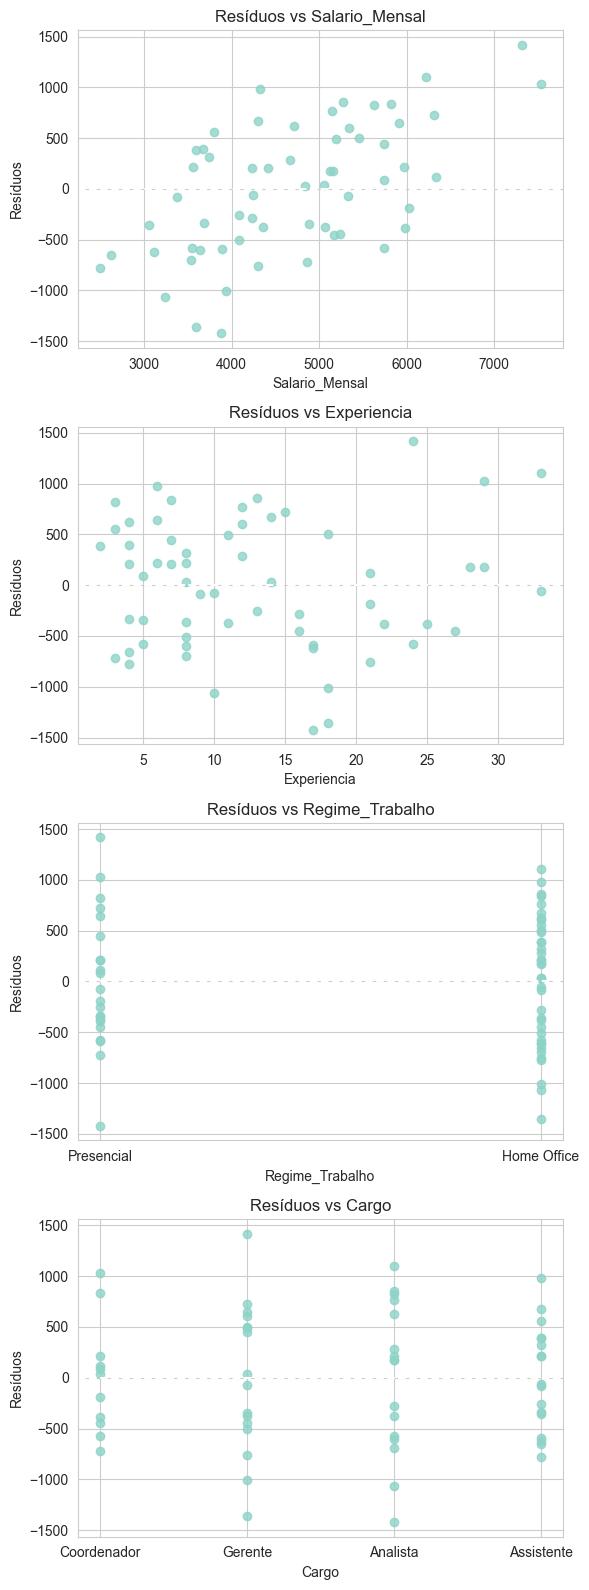

In [10]:
v_plot_residuos(
    df, r["residuos"],
    colunas=["Salario_Mensal", "Experiencia", "Regime_Trabalho", "Cargo"]
)